In [ ]:
!pip install gensim

retrieve---

In [ ]:
import math
import string
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def get_from_file(file_df):
  df=pd.read_csv(file_df)
  df.head()

  x=df['Utterance'].tolist()
  y=df['Dialogue_ID'].tolist()
  return x,y

def tokenize(sentences, is_query=False):
  tokenized_list=[]
  for i in sentences:
    i=i.replace('\x92',"'")
    i=i.replace('\x97','-')
    i=i.replace('\x91',"'")
    i=i.replace('\x93','"')

    token=nltk.word_tokenize(i)

    token = [word.lower() for word in token if word not in string.punctuation and word not in stop_words]

    if is_query:
      tokenized_list.extend(token)
    else:
      tokenized_list.append(token)

  return tokenized_list

In [ ]:
#forming a series of document by joining utterances in the same dialogue

file_train="/content/drive/MyDrive/IR_NLP_2025_Shared/Data/MELD DataSet/train_sent_emo.csv"

utterance,Dialogue_ID=get_from_file(file_train)

temp = defaultdict(list)
for utt, did in zip(utterance, Dialogue_ID):
    temp[did].append(utt)

Dialogues = []

for did in sorted(temp.keys()):
    Dialogues.append(temp[did])

Dialogues_joined=[' '.join(dialogue) for dialogue in Dialogues]
print(Dialogues_joined)


doc_tokens=tokenize(Dialogues_joined)



['also I was the point person on my company\x92s transition from the KL-5 to GR-6 system. You must\x92ve had your hands full. That I did. That I did. So let\x92s talk a little bit about your duties. My duties?  All right. Now you\x92ll be heading a whole division, so you\x92ll have a lot of duties. I see. But there\x92ll be perhaps 30 people under you so you can dump a certain amount on them. Good to know. We can go into detail No don\x92t I beg of you! All right then, we\x92ll have a definite answer for you on Monday, but I think I can say with some confidence, you\x92ll fit in well here. Really?! Absolutely.  You can relax', "But then who? The waitress I went out with last month? You know? Forget it! No-no-no-no, no! Who, who were you talking about? No, I-I-I-I don't, I actually don't know Ok! All right, well... Yeah, sure!", 'Hey, Mon. Hey-hey-hey. You wanna hear something that sucks. Do I ever. Chris says they\x92re closing down the bar. No way! Yeah, apparently they\x92re turning 

In [ ]:
#import gensim.downloader as api
#!pip install gensim

#using gensim for lsa
#tipical step -> inverted index -> tf_idf -> lsa

from gensim.models import TfidfModel
from gensim.corpora import Dictionary
from gensim.models import LsiModel

dct = Dictionary(doc_tokens)  # fit dictionary

corpus = [dct.doc2bow(line) for line in doc_tokens]  # convert corpus to BoW format   (BoW : bag of word)

tfidf_model = TfidfModel(corpus)  # fit model
corpus_tfidf = tfidf_model[corpus]

# LSA (LSI)
r = 200  # reduced dimension
lsa_model = LsiModel(corpus_tfidf, id2word=dct, num_topics=r)

# LSA representation of docs
corpus_lsa = lsa_model[corpus_tfidf]

In [ ]:
from gensim.matutils import cossim

query = "number"
query_tokens = tokenize([query], is_query=True)
query_bow = dct.doc2bow(query_tokens)
query_tfidf = tfidf_model[query_bow]
query_lsa = lsa_model[query_tfidf]

In [ ]:
sims = []
for i, doc_lsa in enumerate(corpus_lsa):
    similarity = cossim(query_lsa, doc_lsa)
    sims.append((i, similarity))

# Decreasing similarity order
sims = sorted(sims, key=lambda x: x[1], reverse=True)


for doc_id, score in sims[:5]:
    print(f"Documento {doc_id} | Similarità: {score:.4f}")
    print(doc_tokens[doc_id])
    print(Dialogues_joined[doc_id])

Documento 804 | Similarità: 0.8137
['hello', 'what', "'s", 'oh', 'right', 'girl', "'s", 'phone', 'number', 'yeah-yeah', 'phone', 'number', 'really', 'hot', 'girl', 'gave', 'it', "'s", 'big', 'deal', 'i', 'mean', 'home', 'phone', 'number', '...', 'whoa', 'whoa-whoops', 'i', 'almost', 'lost', 'baby', 'yeah', 'lovely', 'amanda', 'gives', 'number', 'i-i', 'go', 'drop', 'thank']
Hello! What's this? Oh right its that girl's phone number. Yeah-yeah, there it is, just a phone number a really hot girl gave me. It's no big deal, I mean it is her home phone number, but... Whoa! Whoa-whoops, I almost lost this baby! Yeah, the lovely Amanda gives me her number and I-I go and drop it. Thank you.
Documento 228 | Similarità: 0.5438
['well', 'fun', 'yes', 'yes', 'thanks', 'letting', 'use', 'phone', '...', 'saving', 'life', 'well', 'goodbye', 'chandler', 'i', 'great', 'blackout', 'see', 'ya', 'hi', 'um', 'i', "'m", 'account', 'number', '7143457', 'and', 'uh', 'i', "n't", 'know', 'got', 'i', 'would', 're

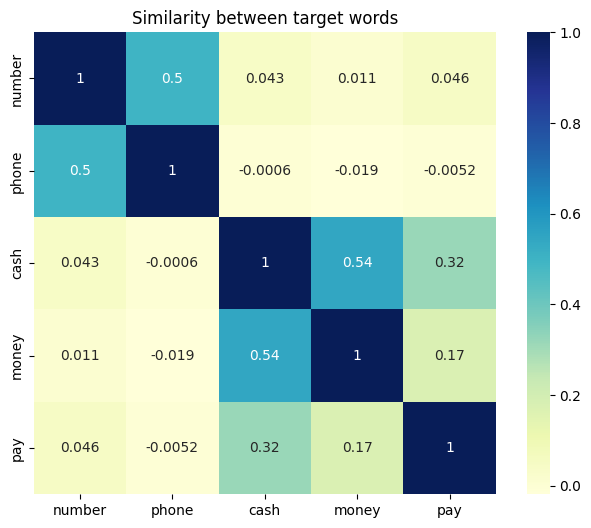

In [ ]:
import pandas as pd
import numpy as np
from gensim.corpora import Dictionary
from gensim.models import TfidfModel, LsiModel
from scipy.spatial.distance import cosine
import seaborn as sns
import matplotlib.pyplot as plt

# calculating correlation between words to vverify if the model recognize similar word

target_words = ["number", "phone","cash","money","pay"]

def get_lsa_vector(word):
    if word in dct.token2id:
        word_bow=dct.doc2bow([word])
        word_tfidf=tfidf_model[word_bow]
        word_lsa=lsa_model[word_tfidf]
        return word_lsa
    else:
        return None



lsa_vectors = {word: get_lsa_vector(word) for word in target_words}

#print(lsa_vectors)

words = list(lsa_vectors.keys())
sim_matrix = np.zeros((len(words), len(words)))

for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):
        sim = cossim(lsa_vectors[w1], lsa_vectors[w2])
        sim_matrix[i, j] = sim

df_sim = pd.DataFrame(sim_matrix, index=words, columns=words)

plt.figure(figsize=(8, 6))
sns.heatmap(df_sim, annot=True, cmap="YlGnBu", square=True)
plt.title("Similarity between target words")
plt.show()
